In the previous part of the tutorial we looked at the effect of distributed renewable generation on the distribution grid, and how storage and peak shaving reduces this effect. In this tutorial we focus on evaluating the positive influence of energy hubs.

An energy hub is a smartly-controlled decentralized energy system within a defined area coordinating their generation, storage, conversion, and consumption to balance the local demand and collaborating towards a common goal.

One of the main advantages of an energy hub is the flexibility of generation and demand. Generation can be tailored to the more specific local needs, and demand can be handled by peak shifting (cooperation) and appropriate storage strategy.

First of all lets install the necessary packages for the visualizations in this tutorial by running the next cell:

In [1]:
%pip install -q ipywidgets
%pip install ipympl
%pip install matplotlib 

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib widget

In [3]:
from illuminator.engine import Simulation
import functions_T3
import pandas as pd
import nest_asyncio
nest_asyncio.apply()

What can we use to evaluate the hubs?
In this step we chose our KPIs; CO2 emissions as a measure for sustainability, cost as a measure of efficiency and grid congestion as a measure for distribution efficiency.

Let's re-run the tutorial 3 simulation in it's worst case scenario, no renewables nor measures for grid congestion, this time we have 100 houses 

In [4]:
%%capture
CONFIG_FILE = 'data\Tutorial_physical_congestion_RES_bat.yaml'
simulation_RES_Bat = Simulation(CONFIG_FILE)

new_settings = {'Wind1': {'p_rated': 0},
                # 'Load1': {'houses': 100},
                'PV1': {'cap': 0},
                # 'Battery1': {'max_p': 40, 'min_p': -40, 'soc_min': 10, 'soc_max': 90},
                'Controller1': {'battery_active': False},
                # 'Grid1':{'connection_capacity' : 150, 'tolerance_limit': 0.67, 'critical_limit': 0.9},
                }

simulation_RES_Bat.edit_models(new_settings)

# you can switch between the selected days 2012-02-01 and 2012-07-06 by changing the date in the two lines below for better readibility it is advised to keep the observed time slot at 1 day
simulation_RES_Bat.set_scenario_param('start_time', '2012-02-01 00:00:00')
simulation_RES_Bat.set_scenario_param('end_time', '2012-02-01 23:45:00')

# run the simulation
simulation_RES_Bat.run()

2026-01-16 16:11:34.983 | INFO     | mosaik.async_scenario:start:508 - Starting 'Collector-0' (based on starter 'Collector')
2026-01-16 16:11:35.765 | INFO     | mosaik.async_scenario:start:508 - Starting 'CSVload-0' (based on starter 'CSVload')
2026-01-16 16:11:35.900 | WARNING  | mosaik.async_scenario:user_warning:360 - c:\Users\dgeorgiadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\mosaik\adapters.py:120: UserWarning: Simulator CSVload-0 is using an outdated API version, namely 1. It should still work. You can suppress this warning by adding an explicit API version for this simulator in your SimConfig.
2026-01-16 16:11:35.902 | INFO     | mosaik.async_scenario:start:508 - Starting 'CSV_pv-0' (based on starter 'CSV_pv')
2026-01-16 16:11:36.055 | WARNING  | mosaik.async_scenario:user_warning:360 - c:\Users\dgeorgiadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\mosaik\adapters.py:120: UserWarning: Simulator CSV_pv-0 is using an outdated API version, namely 1

As we now don't generate with any renewables of our own we are tied to the CO2 production of the Netherlands' grid energy mix. We apply a (variable) CO2 calculation to the power demand, this will be the first KPI.  

We do a similar process to find the effect on cost of electricity, using the intraday market prices for the energy from the grid:

In [5]:
from complete_co2_workflow import align_dates_and_calculate_co2

co2_results = align_dates_and_calculate_co2(
    generation_file='data\GENERATION_PER_TYPE_20251125-20251202.csv',
    consumption_file='out_Tutorial_RES_Bat.csv',
    consumption_column='Controller1.dump',
    consumption_date_column='date',
    output_csv='co2_results.csv'
)

# Step 2: Calculate electricity costs
from electricity_cost_calculator import calculate_electricity_cost

cost_results = calculate_electricity_cost(
    price_file='data\GUI_ENERGY_PRICES_202511272300-202511282300.csv',
    consumption_file='out_Tutorial_RES_Bat.csv',
    consumption_column='Controller1.dump',
    consumption_date_column='date',
    price_date_column='MTU (CET/CEST)',
    price_column='Day-ahead Price (EUR/MWh)',
    output_csv='electricity_cost_results.csv'
)



Total CO2 Emissions:        178.49 kg
                            0.18 tonnes
  Total Cost:               €67.52

✓ Results saved to: electricity_cost_results.csv


Let's visualise these KPIs by running the cell below. Why do you think the plots look so similar?  

In [ ]:
from combined_analysis_plots import plot_combined_analysis

fig, (ax1, ax2) = plot_combined_analysis(
    co2_results_file='co2_results.csv',
    cost_results_file='electricity_cost_results.csv',
    consumption_file='out_Tutorial_RES_Bat.csv',
    connection_cap=150,
    critical_limit=0.9,
    tolerance_limit=0.67,
    figsize=(14, 5)  # You can adjust this if needed
)

FileNotFoundError: [Errno 2] No such file or directory: 'out_Tutorial_5.csv'

In our 100 house energy hub we want to introduce our own renewable energy generation. Flexibility in generation and consumption to match supply to demand is a key advantage of energy hubs.

Run the code and select an amount of PV's, windturbines and storage to match the demand of the chosen hub. 

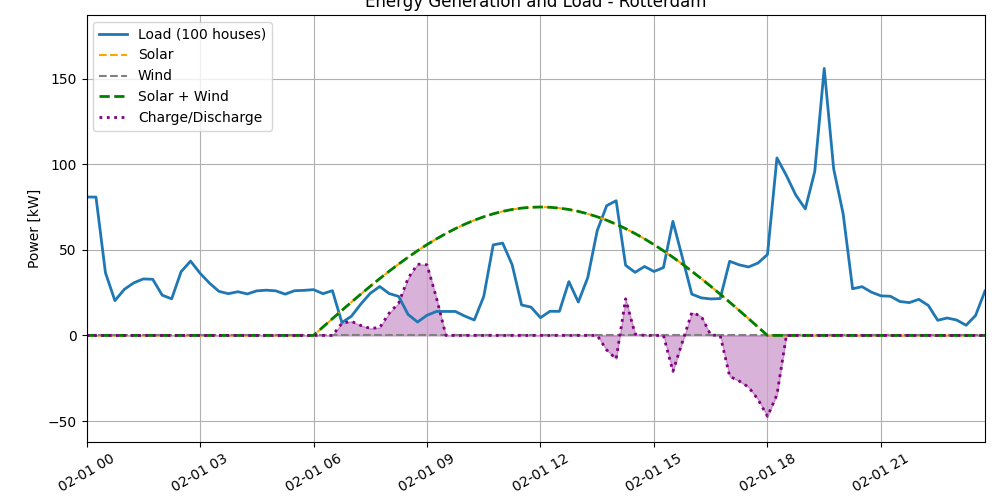

In [ ]:
from energy_dashboard_function import run_energy_dashboard
dashboard = run_energy_dashboard()


Run the simulation and wait for it to finish:

In [8]:
CONFIG_FILE = 'data/Tutorial_physical_congestion_RES_bat.yaml'
test = Simulation(CONFIG_FILE)
test.run()


        ____                              _ _
       /    \                            (_) |
  ____/      \  _ __ ___   ___  ___  __ _ _| | __
 /    \      / | '_ ` _ \ / _ \/ __|/ _` | | |/ /
/      \____/  | | | | | | (_) \__ \ (_| | |   <
\      /    \  |_| |_| |_|\___/|___/\__,_|_|_|\_\
 \____/      \____
 /    \      /    \     mosaik: 3.6.0
/      \____/      \       API: 3.0.14
\      /    \      /    Python: 3.11.9
 \____/      \____/         OS: Windows-10-10.0.26100-SP0
      \      /            Docs: https://mosaik.readthedocs.io/en/3.6.0/
       \____/     Get in touch: https://github.com/orgs/OFFIS-mosaik/discussions

2026-01-16 16:13:39.137 | INFO     | mosaik.async_scenario:start:508 - Starting 'Collector-0' (based on starter 'Collector')


c:\Users\dgeorgiadi\Documents\Illuminator_edu\educational_material\tutorials\energy_hubs\Energy HUB


2026-01-16 16:13:39.982 | INFO     | mosaik.async_scenario:start:508 - Starting 'CSVload-0' (based on starter 'CSVload')


2026-01-16 16:13:40.398 | WARNING  | mosaik.async_scenario:user_warning:360 - c:\Users\dgeorgiadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\mosaik\adapters.py:120: UserWarning: Simulator CSVload-0 is using an outdated API version, namely 1. It should still work. You can suppress this warning by adding an explicit API version for this simulator in your SimConfig.
2026-01-16 16:13:40.399 | INFO     | mosaik.async_scenario:start:508 - Starting 'CSV_pv-0' (based on starter 'CSV_pv')


running extra init
{'CSVload': [Entity(full_id='CSVload-0.time-based_0', model_mock=<mosaik.async_scenario.AsyncModelMock object at 0x0000016AAE053390>, children=[])]}


...

flag warning: None
Load dem: 60.6683129
pv: 0.0
wind: 0.030386611825243277
residual load: 60.637926288174754
battery flow: 0
dump: -60.637926288174754
flag warning: None
Load dem: 80.23242259999999
pv: 0.0
wind: 0.03503228786184891
residual load: 80.19739031213814
battery flow: 0
dump: -80.19739031213814
flag warning: None
Load dem: 84.6681264
pv: 0.0
wind: 0.05927027817151735
residual load: 84.6088561218285
battery flow: 0
dump: -84.6088561218285
flag warning: None
Load dem: 76.39341830000001
pv: 0.0
wind: 0.07383113584869763
residual load: 76.31958716415132
battery flow: 0
dump: -76.31958716415132
flag warning: None
Load dem: 75.0704775
pv: 0.016
wind: 0.09355002668610514
residual load: 74.96092747331389
battery flow: 0
dump: -74.96092747331389
flag warning: None
Load dem: 79.9710812
pv: 0.023
wind: 0.09569558684297959
residual load: 79.85238561315703
battery flow: 0
dump: -79.85238561315703
flag warning: None
Load dem: 76.5227862
pv: 0.017
wind: 0.0983132561056085
residual load: 76.

 71%|███████   | 67/95 [00:00<00:00, 136.21steps/s]

flag warning: None
Load dem: 55.3361613
pv: 0.156
wind: 0.04310632698468379
residual load: 55.13705497301532
battery flow: 0
dump: -55.13705497301532
flag warning: None
Load dem: 22.224194
pv: 0.16
wind: 0.06544180511360771
residual load: 21.998752194886393
battery flow: 0
dump: -21.998752194886393
flag warning: None
Load dem: 22.6082758
pv: 0.164
wind: 0.06377811108839015
residual load: 22.38049768891161
battery flow: 0
dump: -22.38049768891161
flag warning: None
Load dem: 8.779790499999999
pv: 0.168
wind: 0.058022524241738295
residual load: 8.55376797575826
battery flow: 0
dump: -8.55376797575826
flag warning: None
Load dem: 7.9706389
pv: 0.17
wind: 0.08812217869581503
residual load: 7.712516721304185
battery flow: 0
dump: -7.712516721304185
flag warning: None
Load dem: 16.4639305
pv: 0.172
wind: 0.04811599150559436
residual load: 16.243814508494406
battery flow: 0
dump: -16.243814508494406
flag warning: None
Load dem: 78.6293094
pv: 0.174
wind: 0.03892987240041636
residual load: 78.

100%|██████████| 95/95 [00:00<00:00, 124.42steps/s]
2026-01-16 16:13:42.017 | INFO     | mosaik.async_scenario:run:1045 - Simulation finished successfully.


flag warning: None
Load dem: 122.8276341
pv: 0.081
wind: 0.17891534200662554
residual load: 122.56771875799338
battery flow: 0
dump: -122.56771875799338
flag warning: None
Load dem: 68.042366
pv: 0.074
wind: 0.14923127429125843
residual load: 67.81913472570875
battery flow: 0
dump: -67.81913472570875
flag warning: None
Load dem: 33.5157595
pv: 0.063
wind: 0.1005307657070669
residual load: 33.35222873429293
battery flow: 0
dump: -33.35222873429293
flag warning: None
Load dem: 33.9397562
pv: 0.057
wind: 0.08212506941961387
residual load: 33.800631130580385
battery flow: 0
dump: -33.800631130580385
flag warning: None
Load dem: 32.6436534
pv: 0.05
wind: 0.12251618532116004
residual load: 32.47113721467884
battery flow: 0
dump: -32.47113721467884
flag warning: None
Load dem: 18.6157869
pv: 0.042
wind: 0.09101798481344742
residual load: 18.48276891518655
battery flow: 0
dump: -18.48276891518655
flag warning: None
Load dem: 15.5496092
pv: 0.013
wind: 0.07492762008368464
residual load: 15.4616

In [ ]:
# %%capture
# from Slider_set_simulation import run_res_simulation
# sim, re_settings, df = run_res_simulation(dashboard)  
# sim.edit_models(re_settings)
# sim.set_scenario_param('start_time', '2012-02-01 00:00:00')
# sim.set_scenario_param('end_time', '2012-02-01 23:45:00')
# sim.run()


2026-01-16 16:07:56.939 | INFO     | mosaik.async_scenario:start:508 - Starting 'Collector-0' (based on starter 'Collector')


2026-01-16 16:07:57.768 | INFO     | mosaik.async_scenario:start:508 - Starting 'CSVload-0' (based on starter 'CSVload')
2026-01-16 16:07:57.837 | WARNING  | mosaik.async_scenario:user_warning:360 - c:\Users\dgeorgiadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\mosaik\adapters.py:120: UserWarning: Simulator CSVload-0 is using an outdated API version, namely 1. It should still work. You can suppress this warning by adding an explicit API version for this simulator in your SimConfig.
2026-01-16 16:07:57.837 | INFO     | mosaik.async_scenario:start:508 - Starting 'CSV_pv-0' (based on starter 'CSV_pv')
2026-01-16 16:07:57.973 | WARNING  | mosaik.async_scenario:user_warning:360 - c:\Users\dgeorgiadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\mosaik\adapters.py:120: UserWarning: Simulator CSV_pv-0 is using an outdated API version, namely 1. It should still work. You can suppress this warning by adding an explicit API version for this simulator in your SimConfig.

Outputs plot:

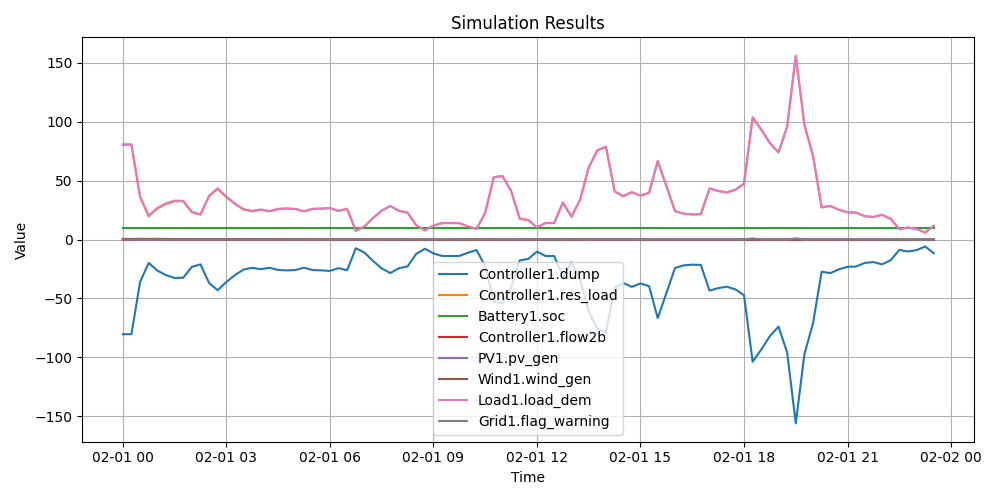

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_simulation_results(
    filepath="./out_Tutorial_5.csv",
    variables=None,
    title="Simulation Results",
    figsize=(10,5)
):
    """
    Plot selected variables from Illuminator output CSV.
    
    Parameters
    ----------
    filepath : str
        Path to the output CSV defined in YAML (monitor.file).
    variables : list of str
        List of columns to plot. If None, will show all available numeric columns.
    title : str
        Title of the plot.
    figsize : tuple
        Figure size.
    """

    # Load the data
    df = pd.read_csv(filepath)

    # Detect time column
    time_col = df.columns[0]
    df[time_col] = pd.to_datetime(df[time_col])

    # Autodetect variables if none specified
    if variables is None:
        variables = [c for c in df.columns if c != time_col]

    # Plot
    plt.figure(figsize=figsize)

    for var in variables:
        if var not in df.columns:
            print(f"⚠ Skipping '{var}' (not in dataset)")
            continue
        plt.plot(df[time_col], df[var], label=var)

    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_simulation_results()


Plot the CO2 emissions, the cost of electricity, and a check on grid congestion


BASELINE (Grid only):
  Total Energy Consumed:    0.79 MWh
  Total Cost:               €65.70
  Mean Price:               €81.35/MWh

Number of timesteps:        95

✓ Results saved to: electricity_cost_results.csv

PLOTTING ELECTRICITY COST BREAKDOWN


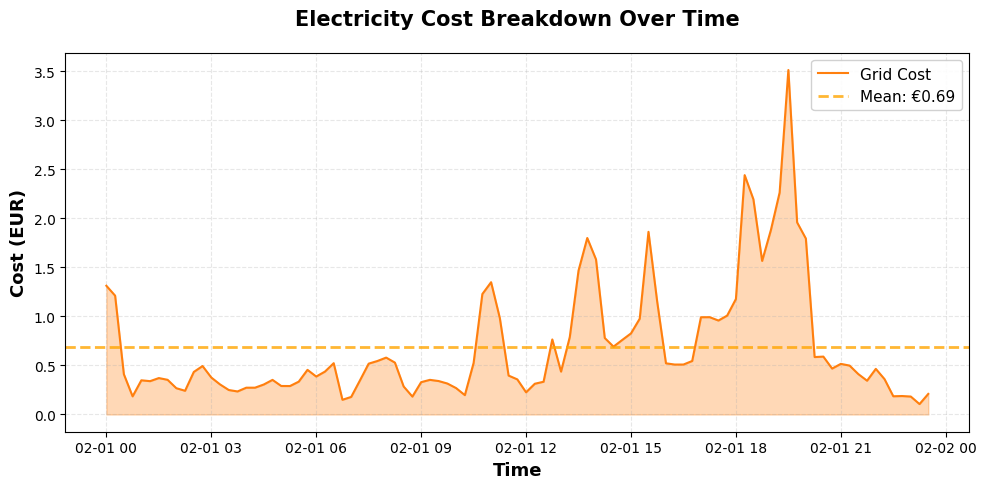

✓ Plot displayed
Total CO2 Emissions:        172.72 kg
                            0.17 tonnes


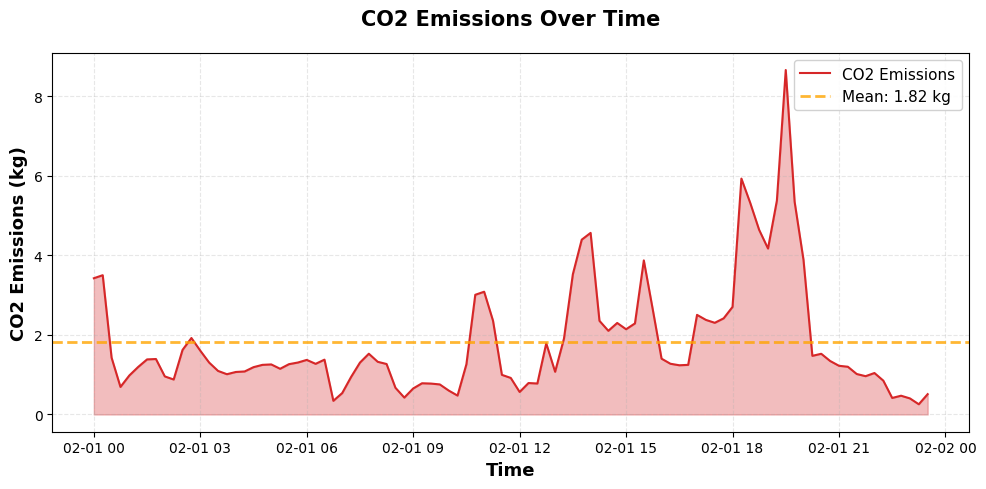

In [ ]:
from electricity_cost_calculator_with_mix_plot import calculate_electricity_cost, plot_electricity_cost

results = calculate_electricity_cost(
    price_file='data\GUI_ENERGY_PRICES_202511272300-202511282300.csv',
    consumption_file='out_Tutorial_Renewables.csv',
    consumption_column='Controller1.dump',
    consumption_date_column='date',
    price_date_column='MTU (CET/CEST)',
    price_column='Day-ahead Price (EUR/MWh)',
    output_csv='electricity_cost_results.csv'
)

plot_electricity_cost(results)
figsize=(10, 5)


from complete_co2_workflow import align_dates_and_calculate_co2, plot_co2_emissions

results = align_dates_and_calculate_co2(
    generation_file='data\GENERATION_PER_TYPE_20251125-20251202.csv',
    consumption_file='out_Tutorial_Renewables.csv',
    consumption_column='Controller1.dump',
    consumption_date_column='date'
)

plot_co2_emissions(results)
figsize=(10, 5)


In [ ]:
from renewable_electricity_cost_calculator2_improved4 import (
    calculate_renewable_and_grid_costs,
    plot_renewable_mix_costs,
    plot_cumulative_costs
)

In [ ]:
# Your slider values
n_pv_panels = dashboard["pv_size_slider"].value      # Number of PV panels
n_wind_turbines = dashboard["n_t_slider"].value       # Number of wind turbines  
battery_capacity = dashboard["storage_slider"].value  # Battery capacity in kWh

# Your file paths
PRICE_FILE = 'data\GUI_ENERGY_PRICES_202511272300-202511282300.csv'
OUTPUT_FILE = 'out_Tutorial_Renewables.csv'

In [ ]:
results = calculate_renewable_and_grid_costs(
    # Files
    price_file=PRICE_FILE,
    consumption_file=OUTPUT_FILE,
    renewable_output_file=OUTPUT_FILE,
    
    # Column names (adjust if different)
    consumption_column='Controller1.dump',
    pv_column='PV1.pv_gen',
    wind_column='Wind1.wind_gen',
    consumption_date_column='date',
    price_date_column='MTU (CET/CEST)',
    price_column='Day-ahead Price (EUR/MWh)',
    
    # System configuration (from sliders)
    n_pv=n_pv_panels,
    n_wind=n_wind_turbines,
    battery_capacity_kWh=battery_capacity,
    
    # LCOE parameters (defaults shown - adjust as needed)
    pv_cost_per_panel_EUR=800,
    pv_capacity_per_panel_kW=0.4,
    pv_lifetime_years=25,
    wind_cost_per_turbine_EUR=50000,
    wind_capacity_per_turbine_kW=10,
    wind_lifetime_years=20,
    battery_cost_per_kWh_EUR=600,
    battery_lifetime_years=10,
    discount_rate=0.05,
    
    # Output
    output_csv='./renewable_grid_cost_results.csv'
)


RENEWABLE AND GRID ELECTRICITY COST CALCULATION

Loading data files...
✓ Price data: 96 rows
✓ Consumption data: 95 rows
✓ Renewable generation data: 95 rows

Consumption starts at: 2012-02-01 00:00:00

Aligning price file dates to consumption dates...
✓ Price dates aligned

CALCULATING LEVELIZED COST OF ENERGY (LCOE)

Validating column names...
✓ PV column 'PV1.pv_gen' found
✓ Wind column 'Wind1.wind_gen' found

Simulation period: 0 days
Annualization factor: 1.00

--- CAPITAL COSTS ---
PV System (150 panels):           €120,000.00
Battery (500 kWh):         €300,000.00
TOTAL CAPITAL COST:                €420,000.00

--- PV LCOE ---
Annual generation:                 0 kWh/year
Lifetime:                          25 years
LCOE:                              €46815.8789/kWh
                                   €46815878.92/MWh

--- BATTERY STORAGE LCOE ---
Battery capacity:                  500 kWh
Lifetime:                          10 years
LCOE (allocated):                  €13416.5687/k


PLOTTING RENEWABLE MIX ELECTRICITY COSTS
Grid costs - Positive periods: 0
Grid costs - Negative periods: 95
Grid costs - Min: -3.51, Max: -0.11
✓ Plotted compensation shading for 95 periods
✓ Plotted negative grid revenue: €65.70

✓ Plot saved to: renewable_mix_costs.png


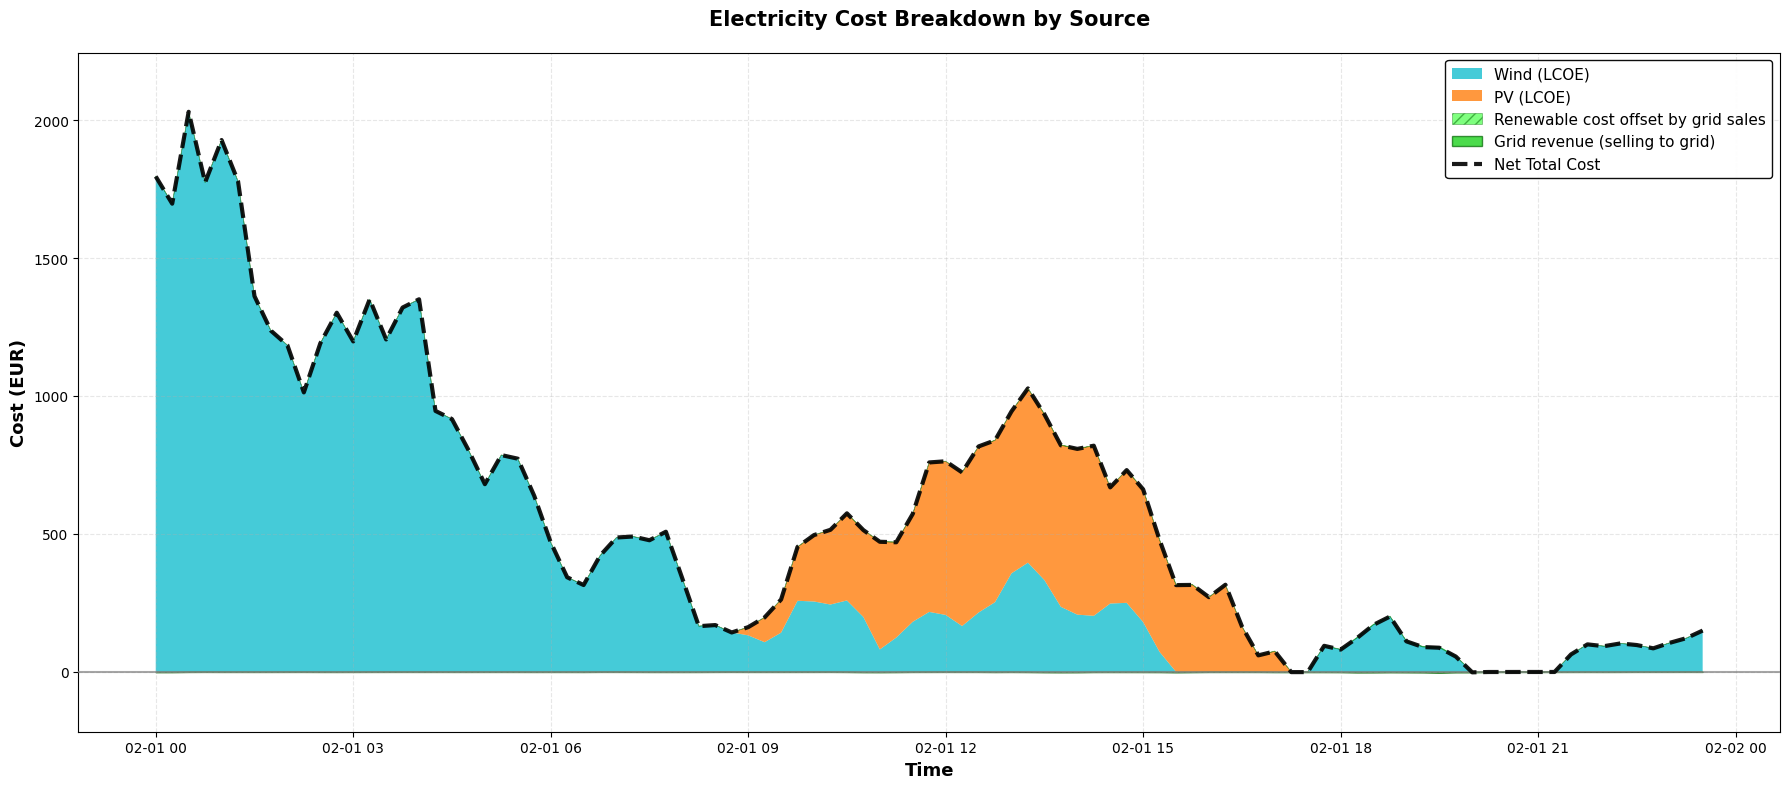


📊 Cost Statistics:
   Total Wind Cost:          €42,067.43
   Total PV Cost:            €12,498.23
   Total Renewable Cost:     €54,565.67
   Total Grid Cost (net):    €-65.70
     - Grid sales revenue:   €65.70
   Net Total Cost:           €54,499.97

💰 Negative Pricing Impact:
   Periods with negative pricing: 95
   Revenue from selling to grid:  €65.70
   Cost reduction from sales:     0.1% of renewable costs

✓ Plot displayed


In [ ]:
# Plot 1: Renewable mix with stacked costs (different colors for each source)
plot_renewable_mix_costs(results)


Energy mix time dependent: https://transparency.entsoe.eu/generation/actual/perType/generation?appState=%7B%22sa%22%3A%5B%22BZN%7C10YNL----------L%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22CHART%22%2C%22df%22%3A%5B%222026-01-15%22%2C%222026-01-15%22%5D%2C%22tz%22%3A%22CET%22%7D

Intraday day-ahead prices: https://transparency.entsoe.eu/market/energyPrices?appState=%7B%22sa%22%3A%5B%22BZN%7C10YNL----------L%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22CHART%22%2C%22df%22%3A%222026-01-15%22%2C%22tz%22%3A%22CET%22%7D

Readjust the amount of PV's, wind and storage and evaluate the effect of your choice. The simulation results are stored in the pages here, page one has the results for the initial case with no renewables 